In [ ]:
!pip install opencv-python
!pip install tensorflow

In [ ]:
from google.colab.patches import cv2_imshow  #for visually showing the image
import cv2
import numpy as np # standard library
import copy  #standard library
import keras    #for creating the model
import matplotlib.pyplot as plt #for visually showing the image
import random

#Dataset Creation (solutions to |1-a,b | 2 | 3)

In [ ]:
(train_images, train_labels),(test_images, test_labels) = keras.datasets.mnist.load_data()
print(len(train_images))

60000


In [ ]:
ax_train = []
ay_train = []                                                              #dataset 1a
for i in range(len(train_labels)):
  test_im = train_images[i]
  _,thresh = cv2.threshold(test_im,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
  ax_train.append(test_im/255.)                                #0-1 range normalisation
  ay_train.append(thresh/255.)
print(len(ax_train),len(ay_train))
print("////////// SPLIT //////////")
ax_test = []
ay_test = []
for i in range(len(test_labels)):
  test_im = test_images[i]
  _,thresh = cv2.threshold(test_im,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
  ax_test.append(test_im/255.)
  ay_test.append(thresh/255.)                                 #0-1 range normalisation
print(len(ax_test),len(ay_test))

60000 60000
////////// SPLIT //////////
10000 10000


In [ ]:
bx_train = []
byl_train = []
byc_train = []
for i in range(len(train_labels)):
  test_im = train_images[i]
  test_lbl = train_labels[i]
  _,thres = cv2.threshold(test_im,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)    #otsu
  contours, _ = cv2.findContours(thres, cv2.RETR_TREE,cv2.CHAIN_APPROX_SIMPLE)
  count = contours[0]
  (x_axis,y_axis),radius = cv2.minEnclosingCircle(count)
  center = (int(x_axis),int(y_axis))  #tight circle center
  radius = int(radius)   #tight circle radius
  cv2.circle(thres,center,radius,255,1)
  bx_train.append(test_im/255.)
  byl_train.append(test_lbl)
  byc_train.append((center[0]/28.,center[1]/28.,radius/28.))
bx_train,byl_train,byc_train = np.array(bx_train),np.array(byl_train),np.array(byc_train)
print(bx_train.shape,byc_train.shape,byl_train.shape)

print("/////////// SPLIT ////////////")

bx_test = []
byl_test = []
byc_test = []
for i in range(len(test_labels)):
  test_im = test_images[i]
  test_lbl = test_labels[i]
  _,thres = cv2.threshold(test_im,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)    #otsu
  contours, _ = cv2.findContours(thres, cv2.RETR_TREE,cv2.CHAIN_APPROX_SIMPLE)
  count = contours[0]
  (x_axis,y_axis),radius = cv2.minEnclosingCircle(count)
  center = (int(x_axis),int(y_axis))  #tight circle center
  radius = int(radius)   #tight circle radius
  cv2.circle(thres,center,radius,255,1)
  bx_test.append(test_im/255.)
  byl_test.append(test_lbl)
  byc_test.append((center[0]/28.,center[1]/28.,radius/28.))
bx_test,byl_test,byc_test = np.array(bx_test),np.array(byl_test),np.array(byc_test)
print(len(bx_test.shape),len(byl_test.shape))

(60000, 28, 28) (60000, 3) (60000,)
/////////// SPLIT ////////////
3 1


In [ ]:
def image2x2_concatenated_dataset(ax_train, ay_train, num_samples=260000):    # >250,000 asked values
    new_images = []
    new_masks = []
    for _ in range(num_samples):
        idxs = random.sample(range(len(ax_train)), 4)    #always random values
        imgs = [ax_train[i] for i in idxs]
        masks = [ay_train[i] for i in idxs]
        imgs = [np.array(im) for im in imgs]
        masks = [np.array(m) for m in masks]
        if imgs[0].ndim == 2:                               #shape correction
            imgs = [im[..., np.newaxis] for im in imgs]
            masks = [m[..., np.newaxis] for m in masks]
        #2×2 grid
        top_row_img = np.concatenate((imgs[0], imgs[1]), axis=1)     #concatenating using numpy's builtin function
        bottom_row_img = np.concatenate((imgs[2], imgs[3]), axis=1)
        new_img = np.concatenate((top_row_img, bottom_row_img), axis=0)
        top_row_mask = np.concatenate((masks[0], masks[1]), axis=1)
        bottom_row_mask = np.concatenate((masks[2], masks[3]), axis=1)
        new_mask = np.concatenate((top_row_mask, bottom_row_mask), axis=0)
        new_images.append(new_img)
        new_masks.append(new_mask)
    return np.array(new_images), np.array(new_masks)

#1c and 4th question solution at the end

In [ ]:
cx_train,cy_train = image2x2_concatenated_dataset(ax_train, ay_train)             #Question Output is after the model
cv2_imshow(cx_train[0])
cv2_imshow(cy_train[0])

#2nd Problem

In [ ]:
def iou_numpy(y, yhat, thresh=0.5):
    y_pred_bin = (yhat >= thresh).astype(np.uint8)
    y_true = y.astype(np.uint8)
    intersection = np.logical_and(y_true, y_pred_bin).sum(axis=(1,2,3))
    union = np.logical_or(y_true, y_pred_bin).sum(axis=(1,2,3))
    iou = (intersection) / (union + 1e-7)
    return iou, y_pred_bin

In [ ]:
###################################################    2nd Question
def convb(x, f):
    for _ in range(2):
        x = keras.layers.Conv2D(f, 3, padding='same', activation='relu')(x)
    return x
x_train,y_train = np.array(ax_train),np.array(ay_train)
x_test,y_test = np.array(ax_test),np.array(ay_test)
inp = keras.Input((28, 28, 1))
c1 = convb(inp, 32); p1 = keras.layers.MaxPooling2D()(c1)
c2 = convb(p1, 64);  p2 = keras.layers.MaxPooling2D()(c2)
b = convb(p2, 128)
u2 = keras.layers.UpSampling2D()(b); u2 = keras.layers.Concatenate()([u2, c2])
c3 = convb(u2, 64)
u1 = keras.layers.UpSampling2D()(c3); u1 = keras.layers.Concatenate()([u1, c1])
c4 = convb(u1, 32)
out = keras.layers.Conv2D(1, 1, activation='sigmoid')(c4)
model = keras.Model(inp, out)
model.compile(optimizer='adam', loss='binary_crossentropy')

model.fit(x_train, y_train, validation_split=0.1, epochs=8, batch_size=64, verbose=2)

Epoch 1/8
844/844 - 25s - 30ms/step - loss: 0.0187 - val_loss: 0.0036
Epoch 2/8
844/844 - 11s - 14ms/step - loss: 0.0028 - val_loss: 0.0024
Epoch 3/8
844/844 - 11s - 13ms/step - loss: 0.0025 - val_loss: 0.0022
Epoch 4/8
844/844 - 11s - 14ms/step - loss: 0.0023 - val_loss: 0.0034
Epoch 5/8
844/844 - 12s - 14ms/step - loss: 0.0023 - val_loss: 0.0034
Epoch 6/8
844/844 - 11s - 14ms/step - loss: 0.0021 - val_loss: 0.0026
Epoch 7/8
844/844 - 11s - 13ms/step - loss: 0.0021 - val_loss: 0.0019
Epoch 8/8
844/844 - 11s - 13ms/step - loss: 0.0020 - val_loss: 0.0020


In [ ]:
print(y_test.reshape(10000,28,28,1).shape)

(10000, 28, 28, 1)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
////////////////
Test Mean IoU: 0.9935
\\\\\\\\\\\\\\\\


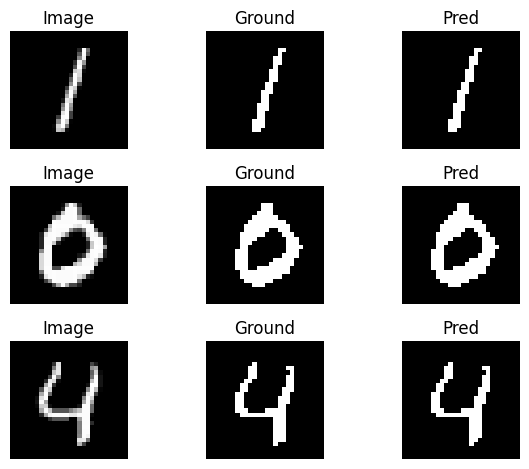

In [ ]:
pred = model.predict(x_test)
y_test = y_test.reshape(10000,28,28,1)
iou, pred_bin = iou_numpy(y_test, pred)
print("////////////////")
print(f"Test Mean IoU: {iou.mean():.4f}")
print("\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\")
for i in range(3):
    plt.subplot(3,3,i*3+1); plt.imshow(x_test[i+2].squeeze(), cmap='gray'); plt.axis('off'); plt.title('Image')
    plt.subplot(3,3,i*3+2); plt.imshow(y_test[i+2].squeeze(), cmap='gray'); plt.axis('off'); plt.title('Ground')
    plt.subplot(3,3,i*3+3); plt.imshow(pred_bin[i+2].squeeze(), cmap='gray'); plt.axis('off'); plt.title('Pred')
plt.tight_layout(); plt.show()

#3rd Problem

In [ ]:
#####################################################                                          3rd question
def build_circlization_model(input_shape=(28, 28, 1), num_classes=10):
    inputs = keras.Input(shape=input_shape)
    x = keras.layers.Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
    x = keras.layers.MaxPooling2D((2,2))(x)
    x = keras.layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = keras.layers.MaxPooling2D((2,2))(x)
    x = keras.layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = keras.layers.Flatten()(x)
    x = keras.layers.Dense(256, activation='relu')(x)
    class_output = keras.layers.Dense(num_classes, activation='softmax', name='class_output')(x)
    circle_output = keras.layers.Dense(3, activation='sigmoid', name='circle_output')(x)     # (sigmoid since cx,cy,r are normalized to [0,1])
    model = keras.models.Model(inputs=inputs, outputs=[class_output, circle_output])
    return model
model = build_circlization_model()
model.compile(optimizer='adam',loss={'class_output': 'sparse_categorical_crossentropy','circle_output': 'mse'},loss_weights={'class_output': 1.0,'circle_output': 0.5},metrics={'class_output': 'accuracy'})
history = model.fit(bx_train,{'class_output': byl_train, 'circle_output': byc_train},validation_data=(bx_test[0:1000], {'class_output': byl_test[0:1000], 'circle_output': byc_test[0:1000]}),epochs=10,batch_size=64)




Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 73s 76ms/step - circle_output_loss: 0.0052 - class_output_accuracy: 0.9159 - class_output_loss: 0.2685 - loss: 0.2711 - val_circle_output_loss: 0.0021 - val_class_output_accuracy: 0.9820 - val_class_output_loss: 0.0527 - val_loss: 0.0535
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 70s 74ms/step - circle_output_loss: 0.0025 - class_output_accuracy: 0.9877 - class_output_loss: 0.0394 - loss: 0.0406 - val_circle_output_loss: 0.0016 - val_class_output_accuracy: 0.9830 - val_class_output_loss: 0.0560 - val_loss: 0.0560
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 75s 80ms/step - circle_output_loss: 0.0022 - class_output_accuracy: 0.9930 - class_output_loss: 0.0234 - loss: 0.0245 - val_circle_output_loss: 0.0013 - val_class_output_accuracy: 0.9910 - val_class_output_loss: 0.0263 - val_loss: 0.0274
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 81s 79ms/step - circle_output_loss: 0.0020 - class_output_accuracy: 0.9943 - class_output_loss: 0.0173 - loss: 0.0183 - val_ci

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


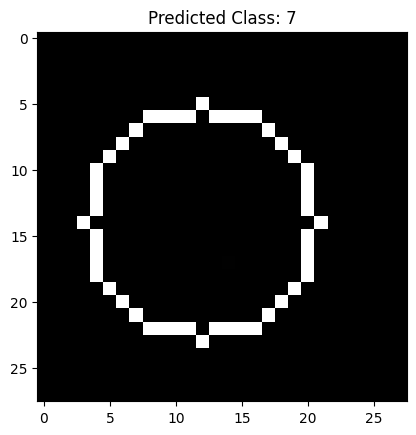

282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step
Mean IoU in % is given by : 76.40581190488615%


In [ ]:
img = bx_test[1100].squeeze()
pred_class, pred_circle = model.predict(bx_test[1100][np.newaxis, ...])
cls = np.argmax(pred_class)
cx, cy, r = pred_circle[0] * [28, 28, 28]
cop = img.copy()
img_vis = cv2.circle(cop, (int(cx), int(cy)), int(r), (255,0,0), 1)
plt.imshow(cop, cmap='gray')
plt.title(f"Predicted Class: {cls}")
plt.show()

pred_class, pred_circle = model.predict(bx_test[1000:len(bx_test)])
validhat = []
valid = []
for idx,i in enumerate(pred_class):       #Handle's Invalid Cases (i.e.. wrong classification)
  if(np.argmax(i)==byl_test[idx+1000]):
    cxp, cyp, rp = pred_circle[idx] * [28,28,28]
    cx, cy, r = byc_test[idx+1000] * [28,28,28]
    cop1,cop2 = np.zeros((28,28,1)),np.zeros((28,28,1))
    cv2.circle(cop1, (int(cxp), int(cyp)), int(rp), 255,-1)
    cv2.circle(cop2, (int(cx), int(cy)), int(r), 255,-1)
    validhat.append(cop1)
    valid.append(cop2)
iou,_ = iou_numpy(np.array(valid),np.array(validhat))
print("Mean IoU in % is given by :",f"{np.mean(iou)*100}%")